In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

## 1. Load Cleaned Data

In [2]:
df = pd.read_csv("../preprocessing/cleaned_data.csv")
print(f"Shape: {df.shape}")
print("\nOriginal Severity distribution:")
print(df["Severity"].value_counts().sort_index())

Shape: (100000, 44)

Original Severity distribution:
Severity
1       98
2    55025
3    44844
4       33
Name: count, dtype: int64


## 2. Select Features

Drop identifiers, raw datetimes, and redundant twilight columns.
Encode categoricals and convert boolean road-feature flags to integers.

In [3]:
DROP_COLS = [
    "Start_Time", "End_Time", "Weather_Timestamp",
    "Street", "City", "County", "Zipcode", "Country",
    "Airport_Code", "Timezone",
    "Civil_Twilight", "Nautical_Twilight", "Astronomical_Twilight",
    "Year", "Day",
]
df = df.drop(columns=[c for c in DROP_COLS if c in df.columns])

ENCODE_COLS = ["State", "Wind_Direction", "Weather_Condition", "Sunrise_Sunset", "DayOfWeek"]
le = LabelEncoder()
for col in ENCODE_COLS:
    df[col] = le.fit_transform(df[col].astype(str))

BOOL_COLS = [
    "Amenity", "Bump", "Crossing", "Give_Way", "Junction", "No_Exit",
    "Railway", "Roundabout", "Station", "Stop", "Traffic_Calming",
    "Traffic_Signal", "Turning_Loop"
]
for col in BOOL_COLS:
    df[col] = df[col].astype(int)

print("Feature count:", df.drop(columns=["Severity"]).shape[1])

Feature count: 28


## 3. Create Binary Target

Severity 1 and 4 have fewer than 100 samples each out of 100k rows, this leads to overfitting of severity 2 and 3.
Merging into two classes solves the imbalance and is more meaningful in practice:
- **0 = Mild** → Severity 1 or 2
- **1 = Severe** → Severity 3 or 4

In [4]:
df["Severity_Binary"] = df["Severity"].apply(lambda x: 0 if x <= 2 else 1)

print("Binary class distribution:")
print(df["Severity_Binary"].value_counts().rename({0: "Mild (1+2)", 1: "Severe (3+4)"}))
print("Unique values in target:", df["Severity_Binary"].unique())

X = df.drop(columns=["Severity", "Severity_Binary"])
y = df["Severity_Binary"]

print("\nX shape:", X.shape)
print("y unique:", y.unique())

Binary class distribution:
Severity_Binary
Mild (1+2)      55123
Severe (3+4)    44877
Name: count, dtype: int64
Unique values in target: [1 0]

X shape: (100000, 28)
y unique: [1 0]


## 4. Train / Test Split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train: {X_train.shape[0]} rows  |  Test: {X_test.shape[0]} rows")
print("\nClass distribution in train:")
print(y_train.value_counts().rename({0: "Mild", 1: "Severe"}))

Train: 80000 rows  |  Test: 20000 rows

Class distribution in train:
Severity_Binary
Mild      44098
Severe    35902
Name: count, dtype: int64


## 5. Train Model

In [6]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("=== Model Results ===")
print(classification_report(
    y_test, y_pred,
    target_names=["Mild", "Severe"],
    labels=[0, 1]
))

=== Model Results ===
              precision    recall  f1-score   support

        Mild       0.87      0.84      0.86     11025
      Severe       0.81      0.85      0.83      8975

    accuracy                           0.85     20000
   macro avg       0.84      0.85      0.84     20000
weighted avg       0.85      0.85      0.85     20000



## Overfitting Check

A gap under 0.05 between train and test means the model generalises well.

In [7]:
y_train_pred = model.predict(X_train)

train_rep = classification_report(y_train, y_train_pred, target_names=["Mild", "Severe"], labels=[0, 1], output_dict=True)
test_rep  = classification_report(y_test,  y_pred,       target_names=["Mild", "Severe"], labels=[0, 1], output_dict=True)

print(f"{"":20} {"Train":>10} {"Test":>10} {"Gap":>10}")
print("-" * 52)
for metric in ["accuracy", "macro avg"]:
    key = "f1-score" if metric == "macro avg" else metric
    tr = train_rep[metric][key] if metric == "macro avg" else train_rep[metric]
    te = test_rep[metric][key]  if metric == "macro avg" else test_rep[metric]
    print(f"{metric:20} {tr:>10.3f} {te:>10.3f} {tr - te:>+10.3f}")
for cls in ["Mild", "Severe"]:
    tr = train_rep[cls]["f1-score"]
    te = test_rep[cls]["f1-score"]
    print(f"F1 {cls:16} {tr:>10.3f} {te:>10.3f} {tr - te:>+10.3f}")

                          Train       Test        Gap
----------------------------------------------------
accuracy                  1.000      0.845     +0.154
macro avg                 1.000      0.844     +0.156
F1 Mild                  1.000      0.857     +0.143
F1 Severe                1.000      0.831     +0.168


## Confusion Matrix

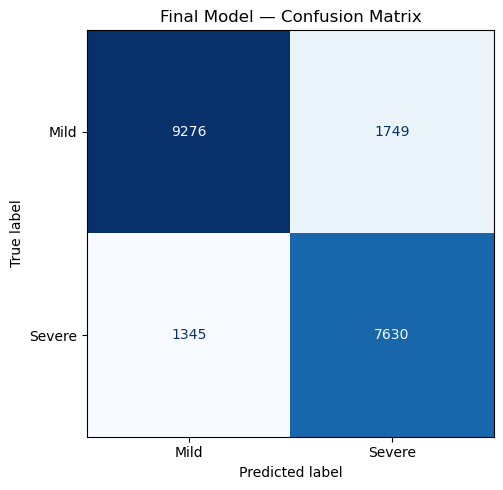

In [8]:
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Mild", "Severe"])

fig, ax = plt.subplots(figsize=(7, 5))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Final Model — Confusion Matrix")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

## 6. Feature Importance

C:\Users\HP Pavilion\AppData\Local\Temp\ipykernel_21608\965815002.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette="Blues_r")


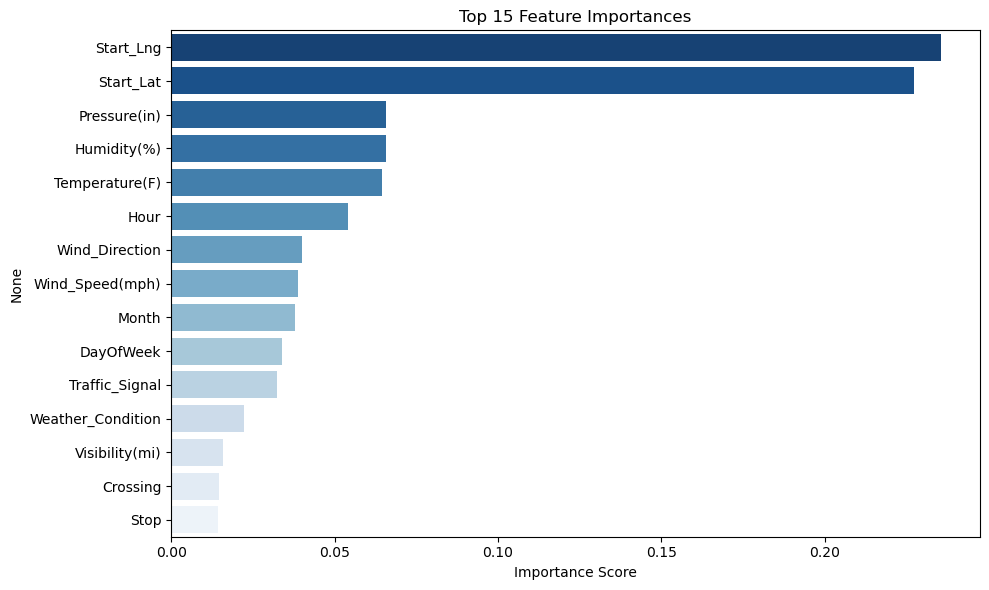

Start_Lng            0.235778
Start_Lat            0.227344
Pressure(in)         0.065772
Humidity(%)          0.065717
Temperature(F)       0.064662
Hour                 0.054040
Wind_Direction       0.039953
Wind_Speed(mph)      0.038802
Month                0.037904
DayOfWeek            0.034048
Traffic_Signal       0.032375
Weather_Condition    0.022217
Visibility(mi)       0.015864
Crossing             0.014504
Stop                 0.014313
dtype: float64


In [9]:
importances = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances.values, y=importances.index, palette="Blues_r")
plt.title("Top 15 Feature Importances")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()

print(importances)

## 7. Save the Model

In [10]:
joblib.dump(model, "model.pkl")
print("Saved as model.pkl")
print("To reload:  model = joblib.load('model.pkl')")

Saved as model.pkl
To reload:  model = joblib.load('model.pkl')
